In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

########################################################################
# The output of torchvision datasets are PILImage images of range [0, 1].
# We transform them to Tensors of normalized range [-1, 1].

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [4]:
########################################################################
# 2. Define a Convolution Neural Network
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Copy the neural network from the Neural Networks section before and modify it to
# take 3-channel images (instead of 1-channel images as it was defined).

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 110)
        self.fc2 = nn.Linear(110, 74)
        self.fc3 = nn.Linear(74, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()



########################################################################
# 4. Train the network
# ^^^^^^^^^^^^^^^^^^^^
#
# This is when things start to get interesting.
# We simply have to loop over our data iterator, and feed the inputs to the
# network and optimize.

epochLoss = {10 : [],
             0.1 : [],
             0.01 : [],
             0.001 : []}
trainAccur = {10 : [],
             0.1 : [],
             0.01 : [],
             0.001 : []}
testAccur = {10 : [],
             0.1 : [],
             0.01 : [],
             0.001 : []}

numEpoch = 20

learning_rates = [10, 0.1, 0.01, 0.001]

import torch.optim as optim

for lr in learning_rates:
    net = Net()  # create a new untrained network

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

    for epoch in range(numEpoch):  # loop over the dataset multiple times
        epoch_loss = 0
        counter = 0
        running_loss = 0.0

        for i, data in enumerate(trainloader, 0):
            # get the inputs
            inputs, labels = data

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            epoch_loss += loss.item()
            counter += 1
            if i % 10000 == 9999:    # print every 10000 mini-batches
                print('[%d, %5d] loss: %.3f' %
                      (epoch + 1, i + 1, running_loss / 10000))
                running_loss = 0.0
        epochLoss[lr].append(epoch_loss / counter)
        epoch_loss = 0
        counter = 0

      # Finding the training accuracy of the model after the epoch

        correct = 0
        total = 0
        with torch.no_grad():
            for data in trainloader:
                images, labels = data
                outputs = net(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        trainAccur[lr].append(100 * correct / total)

        # Finding the test accuracy of the model after the epoch

        correct = 0
        total = 0
        with torch.no_grad():
            for data in testloader:
                images, labels = data
                outputs = net(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        testAccur[lr].append(100 * correct / total)


    print('Finished Training')

[1, 10000] loss: nan
[2, 10000] loss: nan
[3, 10000] loss: nan
[4, 10000] loss: nan
[5, 10000] loss: nan
[6, 10000] loss: nan
[7, 10000] loss: nan
[8, 10000] loss: nan
[9, 10000] loss: nan
[10, 10000] loss: nan
[11, 10000] loss: nan
[12, 10000] loss: nan
[13, 10000] loss: nan
[14, 10000] loss: nan
[15, 10000] loss: nan
[16, 10000] loss: nan
[17, 10000] loss: nan
[18, 10000] loss: nan
[19, 10000] loss: nan
[20, 10000] loss: nan
Finished Training
[1, 10000] loss: 2.359
[2, 10000] loss: 2.360
[3, 10000] loss: 2.358
[4, 10000] loss: 2.360
[5, 10000] loss: 2.361
[6, 10000] loss: 2.359
[7, 10000] loss: 2.362
[8, 10000] loss: 2.360
[9, 10000] loss: 2.359
[10, 10000] loss: 2.361
[11, 10000] loss: 2.358
[12, 10000] loss: 2.361
[13, 10000] loss: 2.361
[14, 10000] loss: 2.359
[15, 10000] loss: 2.359
[16, 10000] loss: 2.359
[17, 10000] loss: 2.360
[18, 10000] loss: 2.360
[19, 10000] loss: 2.360
[20, 10000] loss: 2.361
Finished Training
[1, 10000] loss: 1.993
[2, 10000] loss: 1.971
[3, 10000] loss:

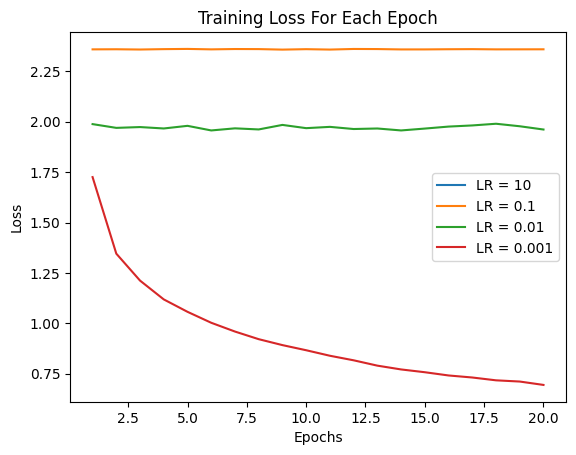

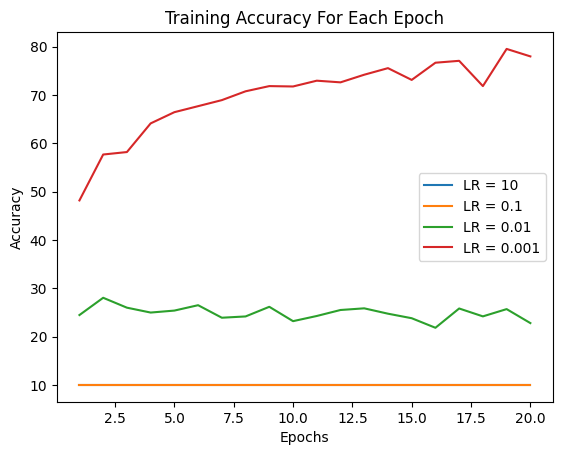

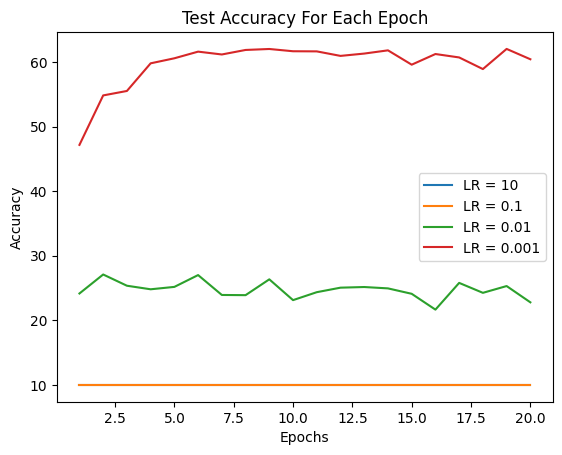

In [5]:

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1,numEpoch+1)

plt.plot(x,epochLoss[10], label= "LR = 10")
plt.plot(x,epochLoss[0.1], label= "LR = 0.1")
plt.plot(x,epochLoss[0.01], label= "LR = 0.01")
plt.plot(x,epochLoss[0.001], label= "LR = 0.001")
plt.title("Training Loss For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(x,trainAccur[10], label= "LR = 10")
plt.plot(x,trainAccur[0.1], label= "LR = 0.1")
plt.plot(x,trainAccur[0.01], label= "LR = 0.01")
plt.plot(x,trainAccur[0.001], label= "LR = 0.001")
plt.title("Training Accuracy For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(x,testAccur[10], label= "LR = 10")
plt.plot(x,testAccur[0.1], label= "LR = 0.1")
plt.plot(x,testAccur[0.01], label= "LR = 0.01")
plt.plot(x,testAccur[0.001], label= "LR = 0.001")
plt.title("Test Accuracy For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()